# OA preliminary-data figures

Quick, recyclable plotting for the preliminary carbonate dataset
(4 cruises, April–December 2025).

This notebook:
- works on **either** the preliminary Excel sheet (`pH_lab`, `omega_ar`, `Station`…)
  **or** the pipeline's `analysis_ready.csv` (`ph_best`, `omega_aragonite_calc`,
  `station_id`…) — it auto-detects which column names are present;
- drops CRM / reference rows automatically;
- overlays **Gulf of Guinea reference guides** (PIRATA pH & TA ranges, atmospheric
  pCO₂, aragonite saturation lines), recycled from the older `make_figures.py`;
- renders inline and (optionally) saves PNGs.

Run cells top to bottom. Edit the **config** cell to point at your file.

In [1]:
# --- imports & config ---
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDIT: path to your data (xlsx or csv) ----------------------------------
INPUT = Path(r"C:\Users\OA_2023-03\Projects\oa_pipeline\data\processed\oa_stage4_outputs\data\analysis_ready.csv")    # or e.g. data/processed/.../analysis_ready.csv
SHEET  = 0                              # sheet name/index for xlsx
OUTDIR = Path("oa_figures")             # where saved PNGs go
SAVE   = True                           # set False to only show inline
REFS   = True                           # overlay Gulf of Guinea reference guides

# Duplicate-precision settings (GOA-ON Cookbook; one place to change):
DUPLICATE_TYPE = "field"     # "field" (sampling+analytical) or "analytical"
QUALITY_TIER   = "weather"   # "weather" (map current state) or "climate" (trends)
# ------------------------------------------------------------------------

# Use the project's publication styling if available (src/viz/style.py).
# Falls back to seaborn defaults if the module isn't importable.
try:
    sys.path.insert(0, str(Path.cwd() / "src"))
    from viz.style import set_pub_defaults, chem, add_panel_label
    set_pub_defaults()
    HAVE_STYLE = True
    print("Using project styling from src/viz/style.py")
except Exception as e:
    HAVE_STYLE = False
    chem = lambda s: s            # noqa: E731  fallback identity
    def add_panel_label(ax, label="a", **k):
        ax.text(0.02, 0.98, f"({label})", transform=ax.transAxes,
                fontweight="bold", va="top", ha="left")
    print(f"Project styling not found ({e}); using seaborn defaults")

OUTDIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200})

Using project styling from src/viz/style.py


## 1. Column auto-detection

`ALIASES` maps a canonical name to the source columns we accept for it. The first
match present in your file wins, so the same notebook handles the prelim sheet and
the pipeline output. Add aliases here if a future file uses different names.

In [2]:
# --- canonical column resolver ---
ALIASES = {
    "ph": ["ph_best", "pH_lab", "ph_lab", "ph_observed"],
    "ph_calc": ["ph_co2sys", "pH_calc", "ph_calc", "ph_calculated"],
    "omega_ar": ["omega_aragonite_calc", "omega_ar"],
    "omega_ca": ["omega_calcite_calc", "omega_ca"],
    "pco2": ["pco2_best_uatm", "pco2_calc_uatm", "pco2"],
    "ta": ["ta_best_umolkg", "ta_corrected_umolkg", "ta"],
    "dic": ["dic_best_umol_kg", "dic_calc", "dic"],
    "revelle": ["revelle_factor_calc", "revelle_factor"],
    "temp_insitu": ["temperature_insitu_c", "temp_insitu"],
    "temp_lab": ["temperature_measurement_c", "temp_lab"],
    "sal": ["salinity", "sal"],
    "oxygen": ["oxygen_umol_l", "o2_umol/L", "o2_umol_l"],
    "chl": ["chlorophyll", "chl"],
    "depth": ["depth_round_m", "Depth", "depth_m", "depth"],
    "date": ["sample_date"],
    "station": ["station_id", "Station"],
    "transect": ["transect_id", "Transect"],
    "cruise": ["Cruise", "cruise_id"],
    "lat": ["latitude_deg", "latitude", "lat"],
    "lon": ["longitude_deg", "longitude", "long", "lon"],
    "kind": ["crm_or_sample", "sample_type"],
}

LABELS = {
    "ph":r"pH$_T$", "ph_calc": "pH (calc)",
    "omega_ar": r"$\Omega_{ar}$", "omega_ca": r"$\Omega_{ca}$",
    "pco2": r"pCO$_2$ ($\mu$atm)",
    "ta": r"TA ($\mu$mol kg$^{-1}$)", "dic": r"DIC ($\mu$mol kg$^{-1}$)",
    "revelle": "Revelle factor",
    "temp_insitu": r"In situ T ($\degree$C)", "temp_lab": r"Lab T ($\degree$C)",
    "sal": "Salinity", "oxygen": r"O$_2$ ($\mu$mol L$^{-1}$)",
    "chl": "Chl-a", "depth": "Depth (m)",
}

def resolve(df):
    found = {}
    for canon, cands in ALIASES.items():
        for c in cands:
            if c in df.columns:
                found[canon] = c
                break
    return found

def label_of(canon):
    return LABELS.get(canon, canon)

## 2. Load & prepare

Reads the file, drops CRM/std rows, coerces numeric columns, parses dates, and
derives a meteorological `season` (DJF/MAM/JJA/SON) from the sample date.

In [3]:
# --- load + prepare ---
_M2S = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",
        6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}

def load(path, sheet):
    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xls", ".xlsm"):
        try: sheet = int(sheet)
        except (TypeError, ValueError): pass
        return pd.read_excel(path, sheet_name=sheet)
    return pd.read_csv(path)

def prep(df, col):
    out = df.copy()
    if "kind" in col:
        k = out[col["kind"]].astype("string").str.strip().str.lower()
        out = out[k.eq("sample")].copy()
    for canon in ["ph","ph_calc","omega_ar","omega_ca","pco2","ta","dic","revelle",
                  "temp_insitu","temp_lab","sal","oxygen","chl","depth","lat","lon"]:
        if canon in col:
            out[col[canon]] = pd.to_numeric(out[col[canon]], errors="coerce")
    if "date" in col:
        out[col["date"]] = pd.to_datetime(out[col["date"]], errors="coerce")
        out["season"] = out[col["date"]].dt.month.map(_M2S)
    return out

df_raw = load(INPUT, SHEET)
col = resolve(df_raw)
df = prep(df_raw, col)
print(f"Loaded {INPUT.name}: {len(df)} sample rows (CRM/std dropped)")
print("Detected columns:", ", ".join(sorted(col)))
df.head()

Loaded analysis_ready.csv: 38 sample rows (CRM/std dropped)
Detected columns: chl, cruise, date, depth, dic, kind, lat, lon, omega_ar, omega_ca, oxygen, pco2, ph, ph_calc, revelle, sal, station, ta, temp_insitu, temp_lab, transect


,sample_tag,id,sample_date,sample_type,lat,long,cruise_id,transect_id,station_id,sample_id,...,flag_audit_dic_values_missing,flag_audit_dic_nonpositive,flag_audit_negative_co2aq,flag_audit_negative_hco3,flag_audit_negative_co3,analysis_audit_reason_fail,analysis_audit_reason_review,analysis_audit_reason_codes,analysis_audit_status,season
0,J1-C1-N6,1,2026-04-15 00:00:00+00:00,sample,5.636,0.017,P4506,jamestown,J1,P4506-J1-260415-4m-OA,...,False,False,False,False,False,NaN,replicate_conflict_carried;stage3_issue,replicate_conflict_carried;stage3_issue,REVIEW,MAM
1,J1-C1-N6(R),2,2026-04-15 00:00:00+00:00,sample,5.636,0.017,P4506,jamestown,J1,P4506-J1-260415-4m-OA,...,False,False,False,False,False,NaN,replicate_conflict_carried;stage3_issue,replicate_conflict_carried;stage3_issue,REVIEW,MAM
2,J1-C1-N3,3,2026-04-15 00:00:00+00:00,sample,5.636,0.017,P4506,jamestown,J1,P4506-J1-260415-25m-OA,...,False,False,False,False,False,NaN,NaN,NaN,PASS,MAM
3,J1-C1-N1,4,2026-04-15 00:00:00+00:00,sample,5.636,0.017,P4506,jamestown,J1,P4506-J1-260415-40m-OA,...,False,False,False,False,False,NaN,NaN,NaN,PASS,MAM
4,J3-C2-N6,5,2026-04-15 00:00:00+00:00,sample,5.235,0.073,P4506,jamestown,J3,P4506-J3-260415-4m-OA,...,False,False,False,False,False,NaN,replicate_conflict_carried;stage3_issue,replicate_conflict_carried;stage3_issue,REVIEW,MAM


## 3. Gulf of Guinea reference guides

Recycled from `make_figures.py`. These overlay regional context: PIRATA observed
ranges for pH and TA, the atmospheric pCO₂ line (~428 µatm — above it the water is
a CO₂ source), tropical SST and salinity envelopes, and the aragonite saturation
reference lines (Ω=1 undersaturation, Ω≈3 stress threshold relevant to shellfish).

In [4]:
# --- Gulf of Guinea reference guides + helpers ---
REF_GOG = {
    "pco2":     {"lines": [(427.9, "Atmosphere ~428")], "bands": []},
    "omega_ar":{"lines":[(1.0,"Undersaturation (Feely et al., 2008)"),(1.7,"Larval break-even (Barton et al., 2012)"),(3.0,"Favorable range")],"bands":[]},
    "omega_ca": {"lines": [(1.0, "undersat. =1")], "bands": []},
    "temp_insitu": {"lines": [], "bands": [(24.0, 30.0, "Tropical SST")]},
    "sal":      {"lines": [], "bands": [(34.0, 36.0, "PIRATA S")]},
    "ph":       {"lines": [], "bands": [(7.44, 8.13, "PIRATA pH")]},
    "ta":       {"lines": [], "bands": [(2220.0, 2440.0, "PIRATA TA")]},
}

def add_refs(ax, canon, axis="y", label=True):
    """Reference lines. For omega_ar draw the 3 cited thresholds; annotate only if label=True."""
    if not REFS:
        return
    line = ax.axhline if axis == "y" else ax.axvline
    if canon == "omega_ar":
        try:
            thr = OMEGA_THRESHOLDS
        except NameError:
            thr = [(1.0,"\u03a9=1",None,"firebrick"),(1.7,"\u03a9=1.7",None,"darkorange"),(3.0,"\u03a9=3",None,"seagreen")]
        for val, lab, cite, color in thr:
            line(val, ls="--", lw=1.0, color=color, alpha=0.85, zorder=1)
            if not label:
                continue
            txt = lab + (f"\n{cite}" if cite else "")
            if axis == "y":
                ax.annotate(txt, xy=(0.995, val), xycoords=("axes fraction", "data"),
                            xytext=(0, 1), textcoords="offset points",
                            ha="right", va="bottom", fontsize=6.5, color=color, alpha=0.9)
            else:
                ax.annotate(txt, xy=(val, 0.995), xycoords=("data", "axes fraction"),
                            xytext=(2, 0), textcoords="offset points",
                            ha="left", va="top", rotation=90, fontsize=6.5, color=color, alpha=0.9)
        return
    ref = REF_GOG.get(canon)
    if not ref:
        return
    span = ax.axhspan if axis == "y" else ax.axvspan
    for lo, hi, _ in ref.get("bands", []):
        span(lo, hi, alpha=0.10, color="green", lw=0, zorder=0)
    for val, _ in ref.get("lines", []):
        col = "firebrick" if val < 2 else "darkorange"
        line(val, ls="--", lw=1.0, color=col, alpha=0.85, zorder=1)

def robust_limits(v, p=(2, 98), pad=0.05):
    v = pd.to_numeric(v, errors="coerce"); v = v[np.isfinite(v)]
    if v.size == 0:
        return None
    lo, hi = np.nanpercentile(v, p)
    if not np.isfinite(hi - lo) or hi == lo:
        d = 0.5 * (abs(lo) if lo else 1.0); lo, hi = lo - d, hi + d
    pp = pad * (hi - lo)
    return lo - pp, hi + pp

def ref_caption(vars_used):
    """Build a one-line explanation of the reference guides shown, for the
    variables actually plotted in a figure. Keeps the key readable."""
    if not REFS:
        return ""
    parts = []
    seen = set()
    for v in vars_used:
        ref = REF_GOG.get(v)
        if not ref:
            continue
        for lo, hi, lab in ref.get("bands", []):
            key = ("band", lab)
            if key not in seen:
                parts.append(f"shaded = {lab} ({lo:g}-{hi:g})"); seen.add(key)
        for val, lab in ref.get("lines", []):
            key = ("line", lab)
            if key not in seen:
                parts.append(f"dashed = {lab}"); seen.add(key)
    return "Reference guides: " + "; ".join(parts) + "." if parts else ""

def add_ref_caption(fig, vars_used, y=-0.02):
    cap = ref_caption(vars_used)
    if cap:
        fig.text(0.5, y, cap, ha="center", va="top", fontsize=8,
                 style="italic", color="0.35", wrap=True)

def _fmt(x, nd=2):
    return f"{x:.{nd}f}" if np.isfinite(x) else "n/a"

def deduce(df, col, group_canon=None):
    """Compute short, factual deductions from the data. Every statement is a
    measured fact (means, extremes, fractions vs reference thresholds), not an
    interpretive claim. Returns a list of strings."""
    out = []
    n = len(df)
    out.append(f"n = {n} sample rows.")
    # group extremes (e.g. by cruise) for the key OA variables
    g = None
    if group_canon and group_canon in col:
        gcol = col[group_canon]
        agg = {}
        for v in ["ph", "omega_ar", "pco2", "temp_insitu"]:
            if v in col:
                agg[v] = (col[v], "mean")
        if agg:
            g = df.groupby(gcol).agg(**{k: vv for k, vv in agg.items()})
    if g is not None and len(g) > 1:
        if "omega_ar" in g:
            lo = g["omega_ar"].idxmin(); hi = g["omega_ar"].idxmax()
            out.append(f"Mean $\Omega_{{ar}}$ lowest at {lo} ({_fmt(g['omega_ar'].min())}) "
                       f"and highest at {hi} ({_fmt(g['omega_ar'].max())}).")
        if "pco2" in g:
            hi = g["pco2"].idxmax()
            out.append(f"Mean pCO$_2$ highest at {hi} ({_fmt(g['pco2'].max(),0)} $\mu$atm).")
    # threshold fractions vs the GoG reference lines
    if "omega_ar" in col:
        oa = pd.to_numeric(df[col["omega_ar"]], errors="coerce")
        f3 = np.nanmean((oa < 3).astype(float)); f1 = np.nanmean((oa < 1).astype(float))
        out.append(f"{f3*100:.0f}% of samples below the stress guide "
                    f"($\Omega_{{ar}}$ about 3); "
                    f"{f1*100:.0f}% below undersaturation ($\Omega_{{ar}}$=1).")
    if "pco2" in col:
        pc = pd.to_numeric(df[col["pco2"]], errors="coerce")
        fa = np.nanmean((pc > 427.9).astype(float))
        out.append(f"{fa*100:.0f}% of samples exceed atmospheric pCO$_2$ (~428 $\mu$atm), "
                    f"i.e. a CO$_2$ source to the atmosphere.")
    return out

def show_deductions(title, lines):
    """Pretty-print deductions inline (and they remain plain text for copying)."""
    import re as _re
    print(f"\n--- {title}: data summary ---")
    for ln in lines:
        clean = ln
        clean = clean.replace("$\\Omega_{{ar}}\\approx$3", "Omega_ar~3")
        clean = clean.replace("$\\Omega_{{ar}}$", "Omega_ar")
        clean = clean.replace("$\\Omega_{ar}$", "Omega_ar")
        clean = clean.replace("pCO$_2$", "pCO2").replace("$\\mu$atm", "uatm")
        clean = clean.replace("CO$_2$", "CO2")
        # strip any remaining simple latex math wrappers/backslashes
        clean = clean.replace("$", "").replace("\\", "")
        clean = _re.sub(r"\{+|\}+", "", clean)
        print("  -", clean)

def show_interpretation(title, paragraphs):
    """Print a clearly-labelled narrative block generated from the data."""
    import textwrap, re as _re
    def _clean(p):
        p = p.replace("$\\Omega_{{ar}}$", "Omega_ar").replace("$\\Omega_{ar}$", "Omega_ar")
        p = p.replace("$\\Omega$", "Omega").replace("$\\degree$C", "degC")
        p = p.replace("pCO$_2$", "pCO2").replace("$\\mu$atm", "uatm").replace("CO$_2$", "CO2")
        p = p.replace("$", "").replace("\\", "")
        return _re.sub(r"\{+|\}+", "", p)
    print(f"\n=== {title}: narrative (generated from the data; citations for the patterns shown) ===")
    for p in paragraphs:
        for line in textwrap.wrap(_clean(p), width=92):
            print("  " + line)
        print()

def transect_gradient_check(df, col, west_to_east):
    """Verify, from the data, whether the stated west->east ordering actually
    holds for the key variables. Returns a short factual line per variable so
    the spatial-gradient claim is anchored in this dataset, not just asserted."""
    if "transect" not in col:
        return []
    present = [t for t in west_to_east if t in set(df[col["transect"]].dropna().unique())]
    if len(present) < 2:
        return []
    means = {}
    for v in ["temp_insitu", "ph", "omega_ar", "pco2", "sal", "ta"]:
        if v in col:
            m = df.groupby(col["transect"])[col[v]].mean()
            means[v] = [m.get(t, float("nan")) for t in present]
    out = [f"West->east order checked as: {' -> '.join(present)}."]
    import numpy as _np
    def _trend(vals):
        x = _np.arange(len(vals)); y = _np.array(vals, float)
        ok = _np.isfinite(y)
        if ok.sum() < 2:
            return 0.0
        return _np.polyfit(x[ok], y[ok], 1)[0]  # slope sign = direction W->E
    for v, lab in [("temp_insitu","temp"),("ph","pH"),("omega_ar","Omega_ar"),
                   ("pco2","pCO2"),("sal","salinity"),("ta","TA")]:
        if v in means:
            s = _trend(means[v])
            direction = "rises" if s > 0 else ("falls" if s < 0 else "flat")
            out.append(f"{lab} {direction} west->east "
                       f"({means[v][0]:.2f} -> {means[v][-1]:.2f}).")
    return out

def narrate_transect(df, col, west_to_east, coverage_note=None):
    """Compose a data-driven narrative of the spatial pattern.

    The story is BUILT FROM the computed extremes and west->east trend
    directions, so its claims match this dataset. The upwelling interpretation
    is asserted only when the cool / low-pH / low-Omega / high-pCO2 coupling
    actually holds; any variable that breaks the gradient is called out rather
    than glossed; literature anchors attach to the patterns that hold; and the
    coverage caveat is appended when sampling is uneven. Returns prose strings.
    """
    import numpy as _np
    if "transect" not in col:
        return []
    present = [t for t in west_to_east if t in set(df[col["transect"]].dropna().unique())]
    if len(present) < 2:
        return []
    west, east = present[0], present[-1]

    def _meanvec(v):
        m = df.groupby(col["transect"])[col[v]].mean()
        return [m.get(t, _np.nan) for t in present]

    def _slope(vals):
        x = _np.arange(len(vals)); y = _np.array(vals, float); ok = _np.isfinite(y)
        return _np.polyfit(x[ok], y[ok], 1)[0] if ok.sum() >= 2 else 0.0

    trend = {}
    for v in ["temp_insitu", "ph", "omega_ar", "pco2", "sal", "ta"]:
        if v in col:
            vec = _meanvec(v)
            trend[v] = (_slope(vec), vec[0], vec[-1])

    story = []

    # Does the upwelling fingerprint hold? cool + low pH + low Omega + high pCO2 in the west
    fp = (trend.get("temp_insitu", (0,))[0] > 0 and   # T rises W->E => west is cooler
          trend.get("ph", (0,))[0] > 0 and            # pH rises W->E => west lower
          trend.get("omega_ar", (0,))[0] > 0 and      # Omega rises W->E => west lower
          trend.get("pco2", (0,))[0] < 0)             # pCO2 falls W->E => west higher

    if fp:
        story.append(
            f"Spatial structure is a coherent west-to-east gradient. {west} (west) carries the "
            f"strongest upwelling signature - cooler, lower-pH, lower-$\Omega_{{ar}}$, "
            f"higher-pCO$_2$ surface water (T {trend['temp_insitu'][1]:.1f} -> "
            f"{trend['temp_insitu'][2]:.1f} $\degree$C, pH {trend['ph'][1]:.2f} -> "
            f"{trend['ph'][2]:.2f}, $\Omega_{{ar}}$ {trend['omega_ar'][1]:.2f} -> "
            f"{trend['omega_ar'][2]:.2f}, pCO$_2$ {trend['pco2'][1]:.0f} -> "
            f"{trend['pco2'][2]:.0f} $\mu$atm) - while {east} (east) is warmer, higher-pH and "
            f"more saturated. These four variables co-vary in the way upwelling predicts, "
            f"pointing to a single dominant control (upwelling intensity) rather than scattered "
            f"local effects."
        )
        story.append(
            "Anchors: the cool / low-pH / low-$\Omega$ / high-pCO$_2$ coupling is the textbook "
            "upwelling fingerprint (Feely et al. 2008), and the Gulf of Guinea has documented "
            "seasonal coastal upwelling (Wiafe & Nyadjro 2015; Djakoure et al. 2017)."
        )
    else:
        # Report what the data actually shows without forcing the upwelling story
        bits = []
        for v, lab in [("temp_insitu","T"),("ph","pH"),("omega_ar","Omega_ar"),("pco2","pCO2")]:
            if v in trend:
                d = "rises" if trend[v][0] > 0 else ("falls" if trend[v][0] < 0 else "is flat")
                bits.append(f"{lab} {d}")
        story.append(
            f"The carbonate variables do not all line up as a single west-to-east upwelling "
            f"gradient in this dataset ({west} -> {east}): " + ", ".join(bits) +
            ". Treat any single-control interpretation with caution here."
        )

    # Salinity / TA: state what the data shows, don't assume an eastward increase
    if "sal" in trend and "ta" in trend:
        s_dir = "higher" if trend["sal"][0] > 0 else "lower"
        t_dir = "higher" if trend["ta"][0] > 0 else "lower"
        if trend["sal"][0] > 0 and trend["ta"][0] > 0:
            story.append(
                f"Salinity and TA are both {s_dir} toward the east "
                f"(S {trend['sal'][1]:.2f} -> {trend['sal'][2]:.2f}, "
                f"TA {trend['ta'][1]:.0f} -> {trend['ta'][2]:.0f}), consistent with the "
                f"oceanic TA-salinity relationship (Lee et al. 2006)."
            )
        else:
            # the wrinkle we found: S/TA do NOT increase eastward
            hi_ta = df.groupby(col["transect"])[col["ta"]].mean().idxmax()
            story.append(
                f"Note: salinity and TA do not increase eastward here (S is {s_dir}, TA is "
                f"{t_dir} west-to-east); the highest mean TA is at {hi_ta}, a local feature "
                f"rather than a clean gradient. The TA-salinity link (Lee et al. 2006) still "
                f"holds sample-by-sample, but not as an eastward trend - state it that way."
            )

    if coverage_note:
        story.append("CAVEAT: " + coverage_note)
    return story

def _save(fig, name):
    if SAVE:
        p = OUTDIR / f"{name}.png"; fig.savefig(p, bbox_inches="tight")
        print(f"saved {p}")

## 4. Time series by cruise

One point per sample across the four cruises, colored by cruise. The seasonal
signal (lower pH / Ω_ar and higher pCO₂ during the August upwelling cruise) shows
up here.

saved oa_figures\timeseries_by_cruise.png


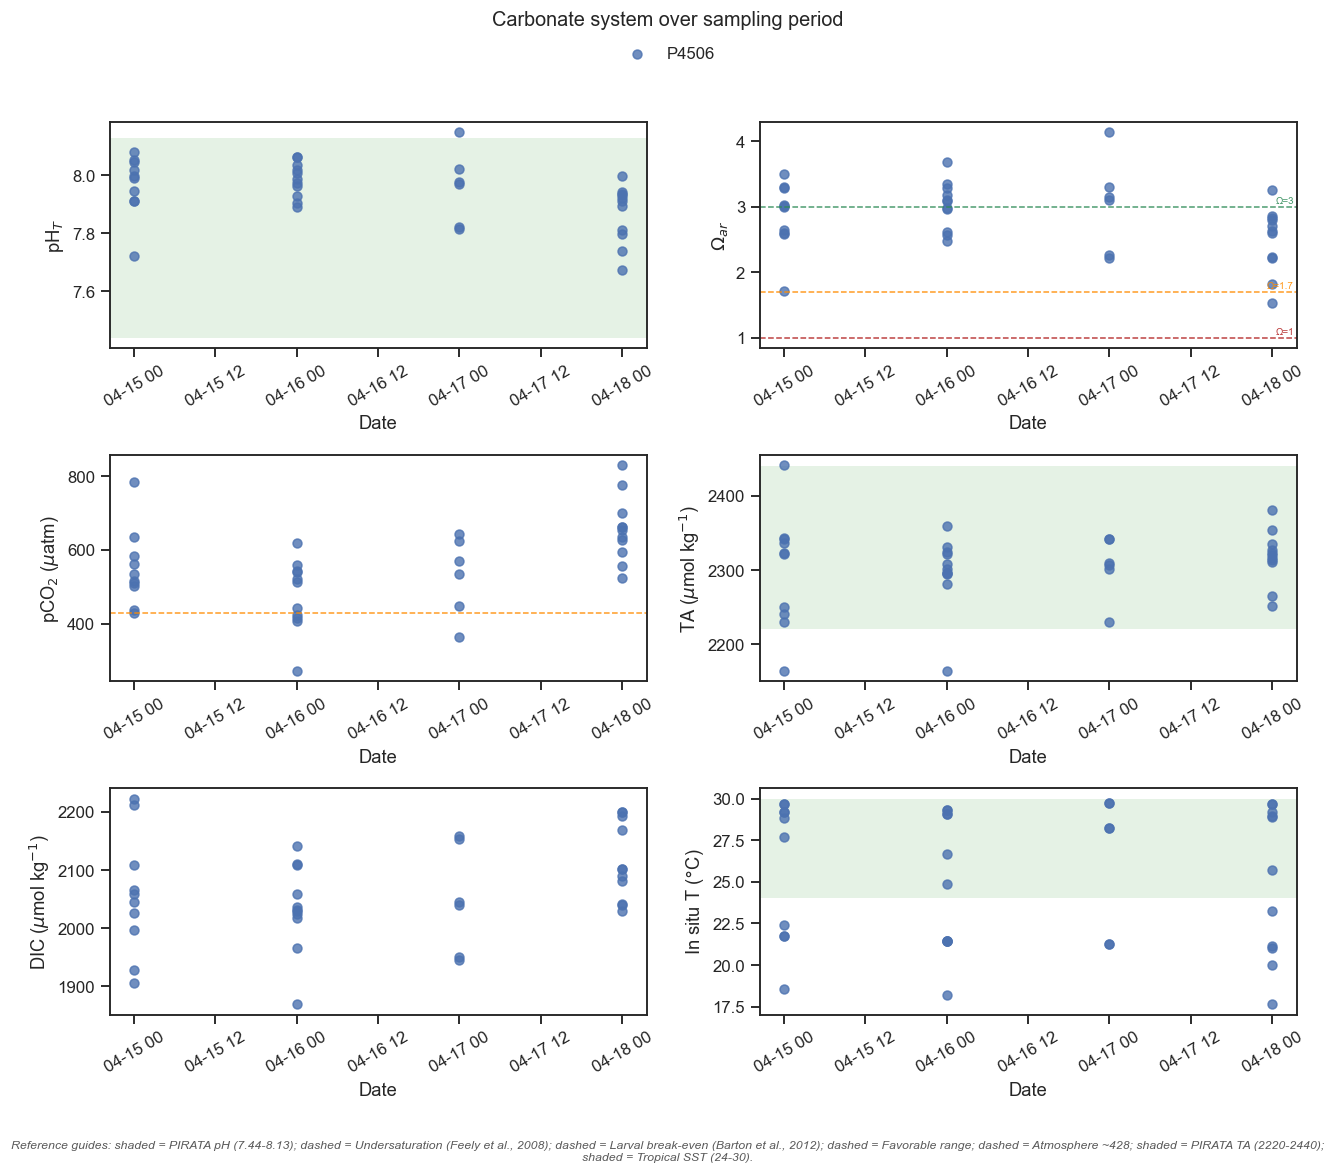


--- Time series: data summary ---
  - n = 38 sample rows.
  - 58% of samples below the stress guide (Omega_ar about 3); 0% below undersaturation (Omega_ar=1).
  - 87% of samples exceed atmospheric pCO2 (~428 uatm), i.e. a CO2 source to the atmosphere.


In [5]:
def fig_timeseries(df, col):
    if "date" not in col:
        print("no date column; skip"); return
    vars_ = [v for v in ["ph","omega_ar","pco2","ta","dic","temp_insitu"] if v in col]
    grp = "cruise" if "cruise" in col else ("transect" if "transect" in col else None)
    n=len(vars_); nrow=(n+1)//2
    fig, axes = plt.subplots(nrow, 2, figsize=(12, 3.2*nrow), squeeze=False)
    for i, v in enumerate(vars_):
        ax = axes[i//2][i%2]
        if grp:
            for g, gd in df.groupby(col[grp]):
                ax.scatter(gd[col["date"]], gd[col[v]], label=str(g), s=34, alpha=0.8)
        else:
            ax.scatter(df[col["date"]], df[col[v]], s=34, alpha=0.8)
        add_refs(ax, v, "y")
        ax.set_ylabel(label_of(v)); ax.set_xlabel("Date"); ax.tick_params(axis="x", rotation=30)
    for j in range(n, nrow*2): axes[j//2][j%2].axis("off")
    if grp:
        h,l = axes[0][0].get_legend_handles_labels()
        fig.legend(h,l, loc="upper center", ncol=min(6,len(l)), bbox_to_anchor=(0.5,1.03))
    fig.suptitle("Carbonate system over sampling period", y=1.05, fontsize=13)
    add_ref_caption(fig, vars_)
    fig.tight_layout(); _save(fig, "timeseries_by_cruise"); plt.show()
    show_deductions("Time series", deduce(df, col, group_canon="cruise"))

fig_timeseries(df, col)

## 5. Seasonal depth profiles

Recycled from `make_season_grid_pub`. Rows are variables, columns are seasons;
each line is a station, colored consistently. Reference guides are drawn on the
x-axis. Depth increases downward.

saved oa_figures\season_depth_profiles.png


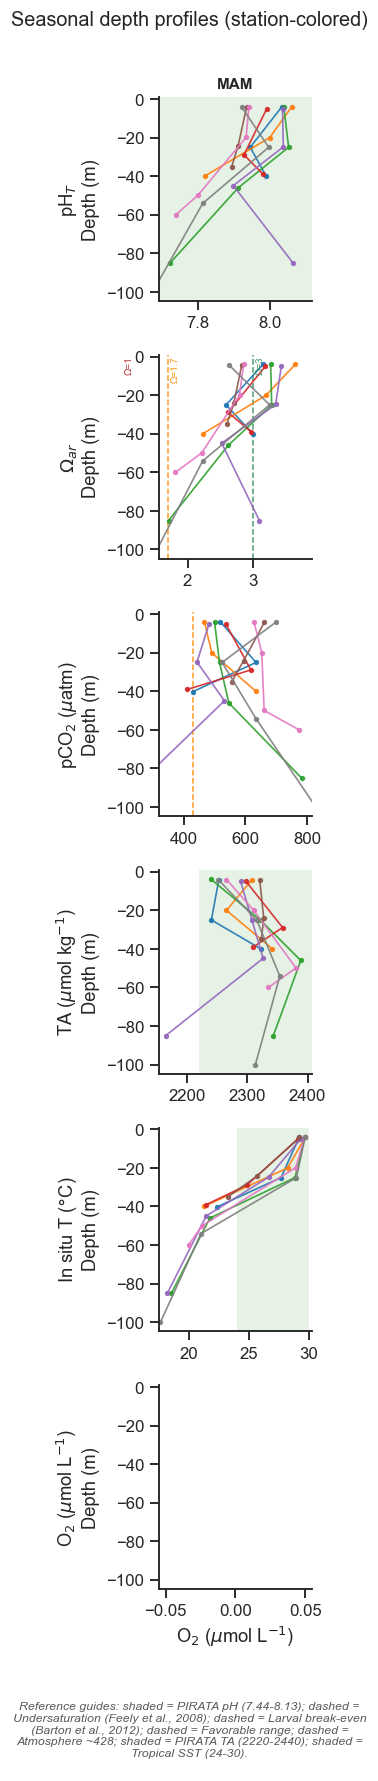

In [6]:
def fig_season_profiles(df, col):
    if "depth" not in col or "season" not in df.columns:
        print("need depth + season; skip"); return
    vars_ = [v for v in ["ph","omega_ar","pco2","ta","temp_insitu","oxygen"] if v in col]
    order = ("DJF","MAM","JJA","SON")
    seasons = sorted(df["season"].dropna().unique(),
                     key=lambda s: order.index(s) if s in order else 99)
    if not vars_ or not seasons:
        print("nothing to plot; skip"); return
    stations = np.sort(df[col["station"]].dropna().unique()) if "station" in col else []
    pal = sns.color_palette("tab10", max(3, len(stations)))
    stc = {s: pal[i%len(pal)] for i,s in enumerate(stations)}
    nrow, ncol = len(vars_), len(seasons)
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.8*ncol, 2.5*nrow), sharey=True, squeeze=False)
    for r, v in enumerate(vars_):
        xlim = robust_limits(df[col[v]])
        for c, seas in enumerate(seasons):
            ax = axes[r][c]; sub = df[df["season"]==seas]
            if sub.empty: ax.set_axis_off(); continue
            if "station" in col:
                g = sub.groupby([col["station"], col["depth"]])[col[v]].mean().reset_index()
                for st, gg in g.groupby(col["station"]):
                    gg = gg.sort_values(col["depth"])
                    ax.plot(gg[col[v]], -gg[col["depth"]], lw=1.1, marker="o", ms=2.5,
                            color=stc.get(st,"0.3"), alpha=0.9)
            else:
                g = sub.groupby(col["depth"])[col[v]].mean().reset_index().sort_values(col["depth"])
                ax.plot(g[col[v]], -g[col["depth"]], lw=1.1, marker="o", ms=2.5, color="0.2")
            add_refs(ax, v, "x")
            if xlim: ax.set_xlim(*xlim)
            if r == nrow-1: ax.set_xlabel(label_of(v))
            ax.set_ylabel(f"{label_of(v)}\nDepth (m)" if c==0 else "")
            if r == 0: ax.set_title(seas, fontsize=10)
            sns.despine(ax=ax)
    fig.suptitle("Seasonal depth profiles (station-colored)", y=1.005, fontsize=13)
    add_ref_caption(fig, vars_)
    fig.tight_layout(); _save(fig, "season_depth_profiles"); plt.show()

fig_season_profiles(df, col)

## 6. Distributions by transect (with GoG guides)

Recycled from `make_by_location_boxplots`. Boxplots of key variables per transect,
with jittered points and the Gulf of Guinea reference bands/lines overlaid.

saved oa_figures\by_transect_boxplots.png


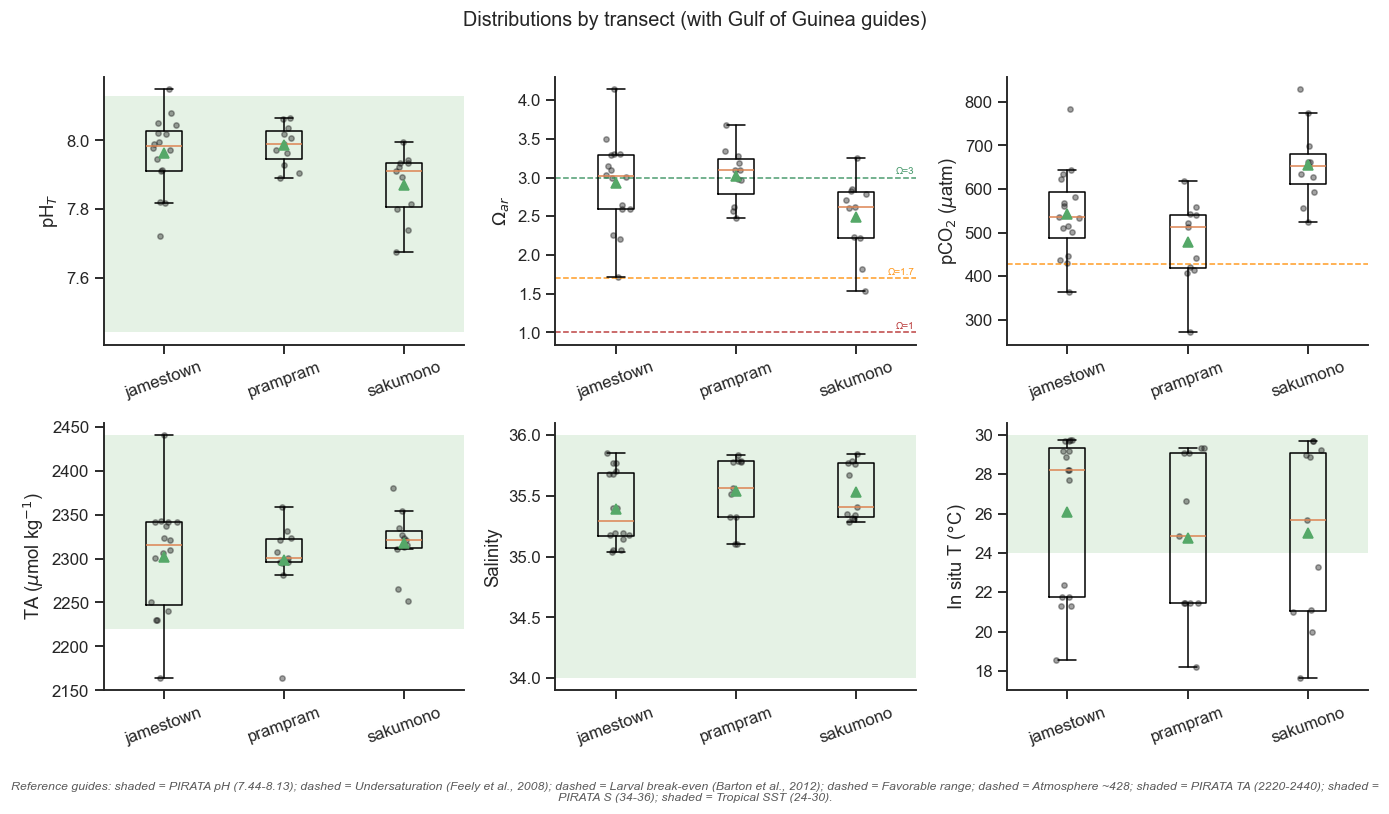


--- By transect: data summary ---
  - n = 38 sample rows.
  - Mean Omega_ar lowest at sakumono (2.50) and highest at prampram (3.03).
  - Mean pCO2 highest at sakumono (656 uatm).
  - 58% of samples below the stress guide (Omega_ar about 3); 0% below undersaturation (Omega_ar=1).
  - 87% of samples exceed atmospheric pCO2 (~428 uatm), i.e. a CO2 source to the atmosphere.


C:\Users\OA_2023-03\AppData\Local\Temp\ipykernel_49164\2056415920.py:36: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  lambda s: sorted(pd.to_datetime(s, errors="coerce").dt.to_period("M").dropna().astype(str).unique()))
C:\Users\OA_2023-03\AppData\Local\Temp\ipykernel_49164\2056415920.py:36: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  lambda s: sorted(pd.to_datetime(s, errors="coerce").dt.to_period("M").dropna().astype(str).unique()))
C:\Users\OA_2023-03\AppData\Local\Temp\ipykernel_49164\2056415920.py:36: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  lambda s: sorted(pd.to_datetime(s, errors="coerce").dt.to_period("M").dropna().astype(str).unique()))


In [7]:
def fig_transect_boxes(df, col):
    if "transect" not in col:
        print("no transect column; skip"); return
    vars_ = [v for v in ["ph","omega_ar","pco2","ta","sal","temp_insitu"] if v in col]
    cats = list(df[col["transect"]].dropna().unique())
    n=len(vars_); ncol=3; nrow=(n+ncol-1)//ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow), squeeze=False)
    for i, v in enumerate(vars_):
        ax = axes[i//ncol][i%ncol]
        data = [df.loc[df[col["transect"]]==c, col[v]].dropna().values for c in cats]
        labels = [str(c) for c in cats]
        try:
            ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
        except TypeError:
            ax.boxplot(data, labels=labels, showfliers=False, showmeans=True)
        for xi, arr in enumerate(data, 1):
            ax.scatter(np.random.normal(xi, 0.05, len(arr)), arr, s=12, alpha=0.4, color="k")
        add_refs(ax, v, "y")
        ax.set_ylabel(label_of(v)); ax.tick_params(axis="x", rotation=20); sns.despine(ax=ax)
    for j in range(n, nrow*ncol): axes[j//ncol][j%ncol].axis("off")
    fig.suptitle("Distributions by transect (with Gulf of Guinea guides)", y=1.01, fontsize=13)
    add_ref_caption(fig, vars_)
    fig.tight_layout(); _save(fig, "by_transect_boxplots"); plt.show()
    show_deductions("By transect", deduce(df, col, group_canon="transect"))

    # Data-backed check of the stated west->east spatial ordering.
    WEST_TO_EAST = ["Jamestown", "Sakumono", "Prampram", "Ayitepa"]
    grad = transect_gradient_check(df, col, WEST_TO_EAST)
    if grad:
        show_deductions("West->east gradient (data)", grad)

    # Auto-detect uneven coverage to decide whether to emit the caveat.
    coverage = None
    if "transect" in col and "date" in col:
        cov = df.groupby(col["transect"])[col["date"]].apply(
            lambda s: sorted(pd.to_datetime(s, errors="coerce").dt.to_period("M").dropna().astype(str).unique()))
        spans = {t: v for t, v in cov.items()}
        n_months = {t: len(v) for t, v in spans.items()}
        if len(set(n_months.values())) > 1:  # uneven month coverage across transects
            sparse = sorted(n_months, key=n_months.get)[:2]
            coverage = ("sampling coverage is uneven across transects and months "
                        + "; ".join(f"{t}: {', '.join(spans[t])}" for t in sparse)
                        + ". In any time-step analysis hold transect constant and avoid pooling, "
                          "or a 'seasonal' signal risks being a spatial-sampling artifact.")

    # Data-driven narrative (story built from the computed pattern, with citations).
    story = narrate_transect(df, col, WEST_TO_EAST, coverage_note=coverage)
    if story:
        show_interpretation("By transect", story)

fig_transect_boxes(df, col)

## 7. Relationships (cross-plots)

Ω_ar vs pH, TA vs salinity (mixing), pCO₂ vs temperature, and Ω_ar vs depth.
Colored by cruise; saturation reference on Ω_ar axes.

Note: you may need to restart the kernel to use updated packages.
saved oa_figures\crossplots.png


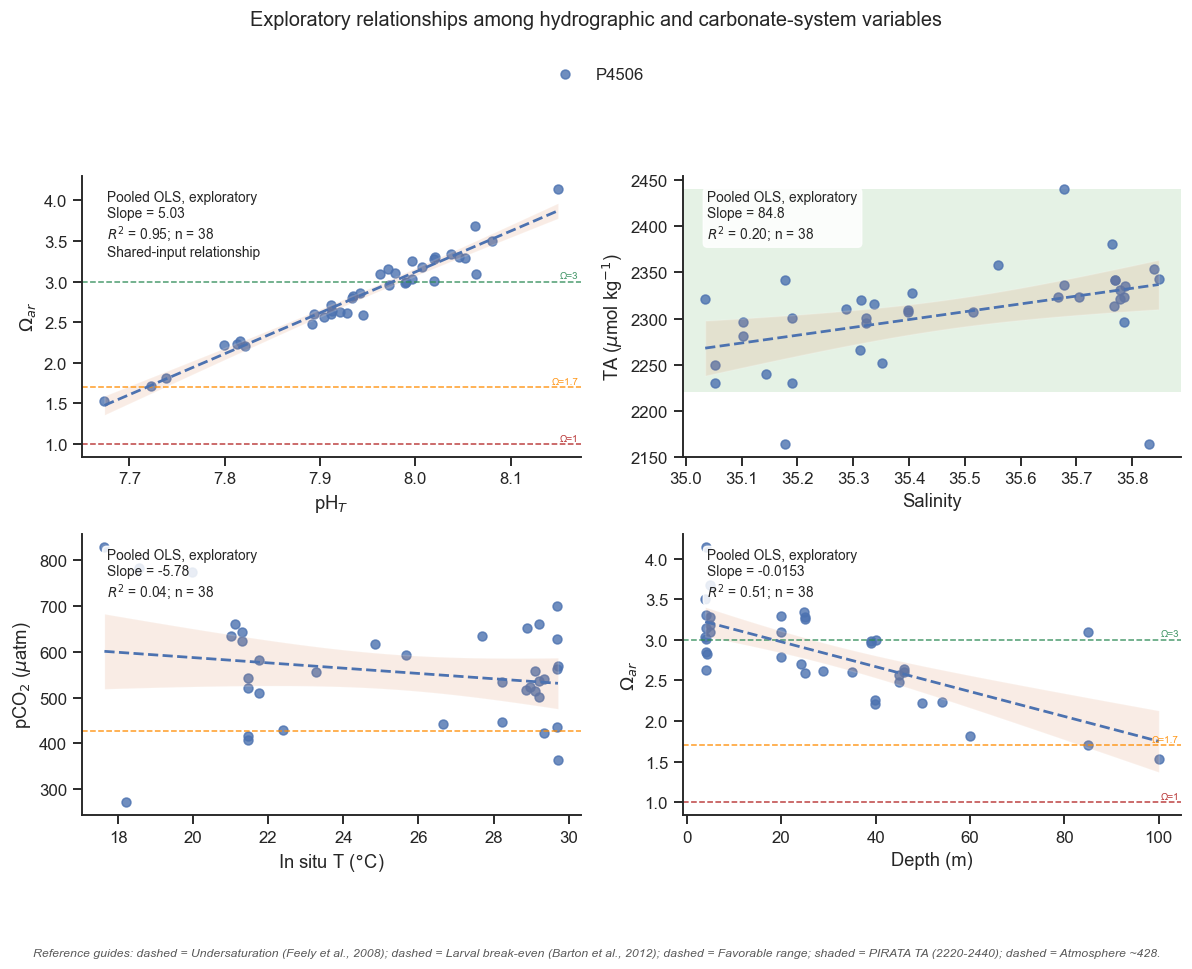

In [8]:
%pip install scipy
from scipy.stats import t as student_t

def fig_crossplots(df, col):
    pairs = [
        ("ph", "omega_ar"),
        ("sal", "ta"),
        ("temp_insitu", "pco2"),
        ("depth", "omega_ar"),
    ]
    pairs = [(x, y) for x, y in pairs if x in col and y in col]

    grp = "cruise" if "cruise" in col else None
    n = len(pairs)
    nrow = (n + 1) // 2

    fig, axes = plt.subplots(
        nrow, 2,
        figsize=(11, 4.2 * nrow),
        squeeze=False
    )

    for i, (xv, yv) in enumerate(pairs):
        ax = axes[i // 2][i % 2]

        # Valid paired observations for the pooled exploratory regression
        plot_df = (
            df[[col[xv], col[yv]]]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        x = plot_df[col[xv]].to_numpy()
        y = plot_df[col[yv]].to_numpy()

        # Plot points, coloured by cruise where available
        if grp:
            for g, gd in df.groupby(col[grp]):
                gd_plot = (
                    gd[[col[xv], col[yv]]]
                    .apply(pd.to_numeric, errors="coerce")
                    .replace([np.inf, -np.inf], np.nan)
                    .dropna()
                )

                ax.scatter(
                    gd_plot[col[xv]],
                    gd_plot[col[yv]],
                    label=str(g),
                    s=34,
                    alpha=0.8
                )
        else:
            ax.scatter(x, y, s=34, alpha=0.8)

        # Pooled ordinary least-squares fit and 95% confidence band
        if len(x) >= 3 and np.unique(x).size > 1:
            slope, intercept = np.polyfit(x, y, 1)
            y_hat = slope * x + intercept

            ss_res = np.sum((y - y_hat) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

            x_line = np.linspace(np.min(x), np.max(x), 200)
            y_line = slope * x_line + intercept

            ax.plot(
                x_line,
                y_line,
                linewidth=1.8,
                linestyle="--",
                label="_nolegend_"
            )

            # 95% confidence interval for the fitted mean relationship
            dof = len(x) - 2
            if dof > 0:
                residual_se = np.sqrt(ss_res / dof)
                x_mean = np.mean(x)
                sxx = np.sum((x - x_mean) ** 2)
                t_crit = student_t.ppf(0.975, dof)

                se_fit = residual_se * np.sqrt(
                    (1 / len(x)) + ((x_line - x_mean) ** 2 / sxx)
                )
                ci = t_crit * se_fit

                ax.fill_between(
                    x_line,
                    y_line - ci,
                    y_line + ci,
                    alpha=0.15
                )

            note = (
                "Pooled OLS, exploratory\n"
                f"Slope = {slope:.3g}\n"
                f"$R^2$ = {r2:.2f}; n = {len(x)}"
            )

            # This association partly reflects the shared carbonate-system inputs
            if (xv, yv) == ("ph", "omega_ar"):
                note += "\nShared-input relationship"

            ax.text(
                0.05, 0.95,
                note,
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85)
            )

        add_refs(ax, yv, "y")
        ax.set_xlabel(label_of(xv))
        ax.set_ylabel(label_of(yv))
        sns.despine(ax=ax)

    # Hide unused panels
    for j in range(n, nrow * 2):
        axes[j // 2][j % 2].axis("off")

    # Shared legend for cruises
    if grp:
        h, l = axes[0][0].get_legend_handles_labels()
        fig.legend(
            h, l,
            loc="upper center",
            ncol=min(6, len(l)),
            bbox_to_anchor=(0.5, 0.95)
        )
        top_margin = 0.88
    else:
        top_margin = 0.94

    fig.suptitle(
        "Exploratory relationships among hydrographic and carbonate-system variables",
        y=0.995,
        fontsize=13
    )

    add_ref_caption(fig, [yv for _, yv in pairs])
    fig.tight_layout(rect=[0, 0.04, 1, top_margin])

    _save(fig, "crossplots")
    plt.show()

fig_crossplots(df, col)

## 8. Station map (cartopy coastline, with graceful fallback)

Adapted from the old `make_profiles.py`. If **cartopy** is installed it draws a
proper coastline/land map using cartopy's built-in features (no local ETOPO
bathymetry file required); otherwise it falls back to a plain lon/lat scatter with
correct aspect. Points are colored by Ω_ar (or pH). For a full bathymetric
backdrop later, drop an ETOPO subset in and extend this cell.

saved oa_figures\station_map.png


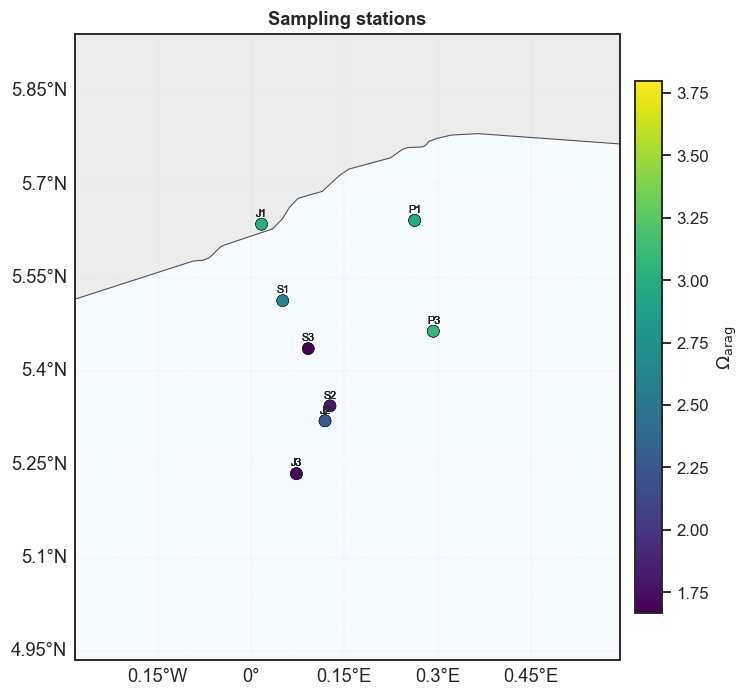

In [9]:
def fig_map(df, col):
    if "lat" not in col or "lon" not in col:
        print("no lat/lon; skip"); return
    cvar = "omega_ar" if "omega_ar" in col else ("ph" if "ph" in col else None)
    d = df.dropna(subset=[col["lat"], col["lon"]]).copy()
    if d.empty:
        print("no coordinates; skip"); return

    # color scaling
    vmin = vmax = None
    if cvar:
        vals = d[col[cvar]].to_numpy()
        if np.isfinite(vals).any():
            vmin, vmax = np.nanpercentile(vals, [2, 98])

    # --- try cartopy (built-in coastlines, no ETOPO needed) ---
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        proj = ccrs.PlateCarree()
        pad = 0.3
        lon0, lon1 = d[col["lon"]].min()-pad, d[col["lon"]].max()+pad
        lat0, lat1 = d[col["lat"]].min()-pad, d[col["lat"]].max()+pad
        fig = plt.figure(figsize=(7.5, 6.5))
        ax = plt.axes(projection=proj)
        ax.set_extent([lon0, lon1, lat0, lat1], crs=proj)
        ax.add_feature(cfeature.LAND, facecolor="#ececec", zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="#f6fbff", zorder=0)
        ax.coastlines(resolution="10m", linewidth=0.7, color="0.3", zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.5", zorder=2)
        if cvar:
            s = ax.scatter(d[col["lon"]], d[col["lat"]], c=d[col[cvar]], cmap="viridis",
                           vmin=vmin, vmax=vmax, s=60, edgecolor="k", linewidth=0.3,
                           transform=proj, zorder=3)
            cb = fig.colorbar(s, ax=ax, shrink=0.85, pad=0.02)
            cb.set_label(chem("Omega_ar") if cvar == "omega_ar" else "pH")
        else:
            ax.scatter(d[col["lon"]], d[col["lat"]], s=50, transform=proj, zorder=3)
        if "station" in col:
            for x, y, lab in zip(d[col["lon"]], d[col["lat"]], d[col["station"]]):
                ax.annotate(str(lab), (x, y), xytext=(0, 5), textcoords="offset points",
                            ha="center", fontsize=7, transform=proj)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.3, alpha=0.4)
        gl.top_labels = gl.right_labels = False
        ax.set_title("Sampling stations")
        fig.tight_layout(); _save(fig, "station_map"); plt.show()
        return
    except Exception as e:
        print(f"cartopy unavailable ({type(e).__name__}); plain scatter fallback")

    # --- fallback: plain lon/lat scatter with geographic aspect ---
    fig, ax = plt.subplots(figsize=(7, 6))
    if cvar:
        s = ax.scatter(d[col["lon"]], d[col["lat"]], c=d[col[cvar]], cmap="viridis",
                       vmin=vmin, vmax=vmax, s=55, edgecolor="k", linewidth=0.3)
        fig.colorbar(s, ax=ax, label=(chem("Omega_ar") if cvar == "omega_ar" else "pH"))
    else:
        ax.scatter(d[col["lon"]], d[col["lat"]], s=45)
    if "station" in col:
        for x, y, lab in zip(d[col["lon"]], d[col["lat"]], d[col["station"]]):
            ax.annotate(str(lab), (x, y), xytext=(0, 5), textcoords="offset points",
                        ha="center", fontsize=7)
    midlat = float(d[col["lat"]].mean())
    ax.set_aspect(1.0 / np.cos(np.deg2rad(midlat)))   # geographic aspect
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("Sampling stations"); sns.despine(ax=ax)
    fig.tight_layout(); _save(fig, "station_map"); plt.show()

fig_map(df, col)

## 6b. East → West transect box plots (ordered, points overlaid)

The spatial figure for the report/slides: transects ordered **geographically west→east** with individual points over each box (sample sizes are uneven, so the points keep small-n boxes honest). `single="omega_ar"` gives a clean one-panel slide figure; the default multi-panel is the report version. Surface-only (≤10 m) by default so the spatial signal isn't confounded with depth.

saved oa_figures\eastwest_omega_slide.png


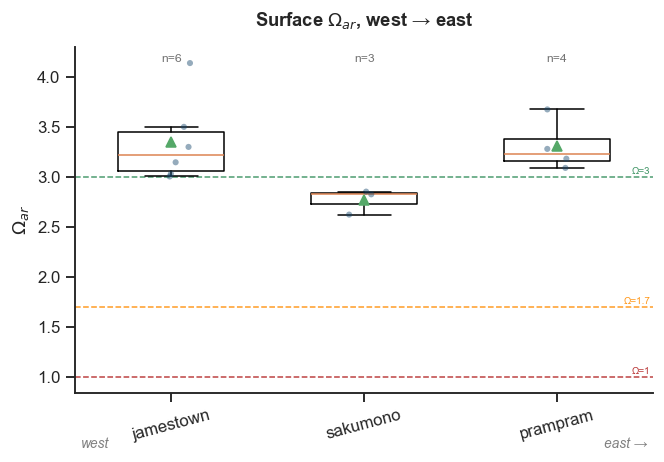

saved oa_figures\eastwest_multipanel.png


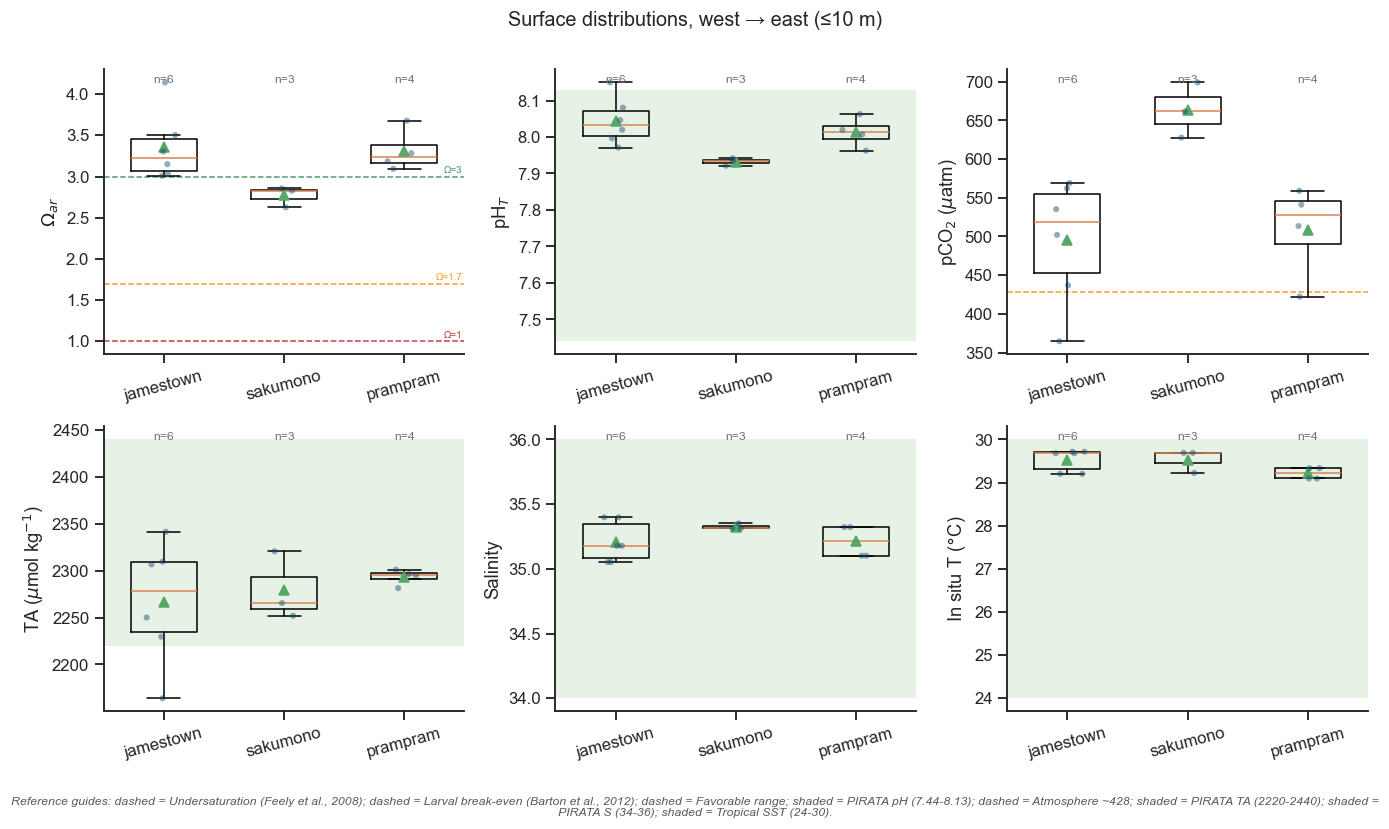

In [10]:
# --- East -> West ordered transect box plots (single + multi-panel) ---
# Reuses resolve()/col, add_refs(), label_of(), _save(), and the project styling.
# Boxes are ordered geographically W->E; individual points are overlaid (sample
# sizes are uneven, so showing the points keeps small-n boxes honest).

WEST_TO_EAST = ["Jamestown", "Sakumono", "Prampram", "Ayitepa"]

def _ordered_cats(d, col, order):
    present_actual = list(d[col["transect"]].dropna().unique())
    present_lower = {str(x).strip().lower(): x for x in present_actual}
    cats = [present_lower[t.lower()] for t in order if t.lower() in present_lower]
    cats += [x for x in present_actual if x not in cats]   # any unexpected transects last
    return cats

def fig_eastwest_box(df, col, vars_=None, single=None,
                     surface_only=True, depth_max=10.0, save_name=None):
    """West->east transect box plots with points overlaid.
    single=<canon>  -> one clean panel (good for a slide)
    vars_=[...]      -> multi-panel grid (good for the report); defaults to the 6 OA vars
    surface_only     -> restrict to depth <= depth_max so spatial != depth signal
    """
    if "transect" not in col:
        print("no transect column; skip"); return
    d = df.copy()
    if surface_only and "depth" in col:
        d = d[pd.to_numeric(d[col["depth"]], errors="coerce") <= depth_max]
    cats = _ordered_cats(d, col, WEST_TO_EAST)

    if single:
        vars_ = [single]
        fig, ax = plt.subplots(figsize=(6.2, 4.4)); axes = [ax]
    else:
        if vars_ is None:
            vars_ = [v for v in ["omega_ar","ph","pco2","ta","sal","temp_insitu"] if v in col]
        ncol = 3; nrow = (len(vars_) + ncol - 1) // ncol
        fig, axs = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.5*nrow), squeeze=False)
        axes = [axs[i//ncol][i%ncol] for i in range(len(vars_))]
        for j in range(len(vars_), nrow*ncol):
            axs[j//ncol][j%ncol].axis("off")

    for i, v in enumerate(vars_):
        ax = axes[i]
        data = [d.loc[d[col["transect"]] == c, col[v]].dropna().values for c in cats]
        ns = [len(a) for a in data]
        try:
            ax.boxplot(data, tick_labels=[str(c) for c in cats],
                       showfliers=False, showmeans=True, widths=0.55)
        except TypeError:
            ax.boxplot(data, labels=[str(c) for c in cats],
                       showfliers=False, showmeans=True, widths=0.55)
        for xi, arr in enumerate(data, 1):
            ax.scatter(np.random.normal(xi, 0.06, len(arr)), arr,
                       s=16, alpha=0.45, color="#15466b", zorder=3, edgecolor="none")
        add_refs(ax, v, "y", label=(i==0 and v=="omega_ar"))
        # n-labels placed just inside the top of the axes (no title collision)
        for xi, nn in enumerate(ns, 1):
            ax.annotate(f"n={nn}", (xi, 0.98), xycoords=("data", "axes fraction"),
                        ha="center", va="top", fontsize=8, color="0.45")
        ax.set_ylabel(label_of(v)); ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=15)
        try: sns.despine(ax=ax)
        except Exception: pass

    if single:
        axes[0].set_title("Surface " + label_of(single) + ", west \u2192 east", fontsize=12, pad=14)
        axes[0].annotate("west", (0.01, -0.16), xycoords="axes fraction",
                         fontsize=9, color="0.5", style="italic")
        axes[0].annotate("east \u2192", (0.99, -0.16), xycoords="axes fraction",
                         fontsize=9, color="0.5", style="italic", ha="right")
    else:
        fig.suptitle("Surface distributions, west \u2192 east"
                     + (f" (\u2264{depth_max:g} m)" if surface_only else ""),
                     y=1.00, fontsize=13)
        add_ref_caption(fig, vars_)

    fig.tight_layout()
    _save(fig, save_name or ("eastwest_" + (single if single else "multi")))
    plt.show()

    # data-anchored deductions + the west->east gradient narrative (reused machinery)
    grad = transect_gradient_check(d, col, WEST_TO_EAST)
    if grad:
        show_deductions("West\u2192east gradient (surface, data)", grad)
    story = narrate_transect(d, col, WEST_TO_EAST)
    if story:
        show_interpretation("West\u2192east spatial pattern", story)

# Slide version: one clean Omega panel
fig_eastwest_box(df, col, single="omega_ar", save_name="eastwest_omega_slide")
# Report version: full multi-panel
fig_eastwest_box(df, col, save_name="eastwest_multipanel")


## 6c. All-sites seasonal & depth-season figures (report Figures 2 & 3)

Extends the seasonal and depth-by-season views to **all four transects** (the originals were Sakumono-only). Lines connect discrete survey points only — not continuous monthly observation. Temperature is overlaid only where a site has ≥3 sampled months. The depth figure keeps all sites and shows empty cells honestly where no samples exist (e.g. Ayitepa has no August). Every point/bar is annotated with its sample count *n*.

C:\Users\OA_2023-03\AppData\Local\Temp\ipykernel_49164\241293102.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower right", fontsize=9, ncol=2)


saved oa_figures\seasonal_all_sites.png


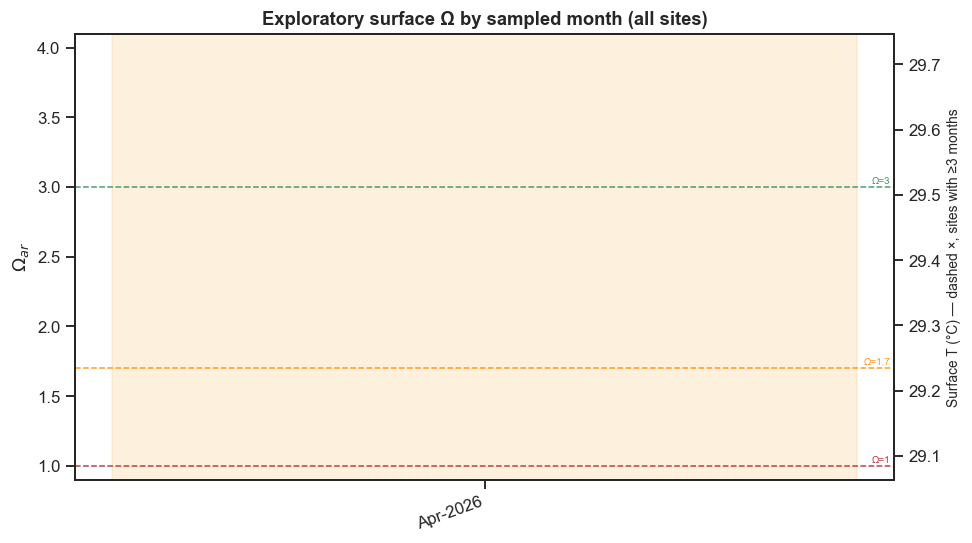

C:\Users\OA_2023-03\AppData\Local\Temp\ipykernel_49164\241293102.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][0].legend(title="Depth (bar label = n)", fontsize=8, title_fontsize=9, loc="upper right")


saved oa_figures\depth_season_all_sites.png


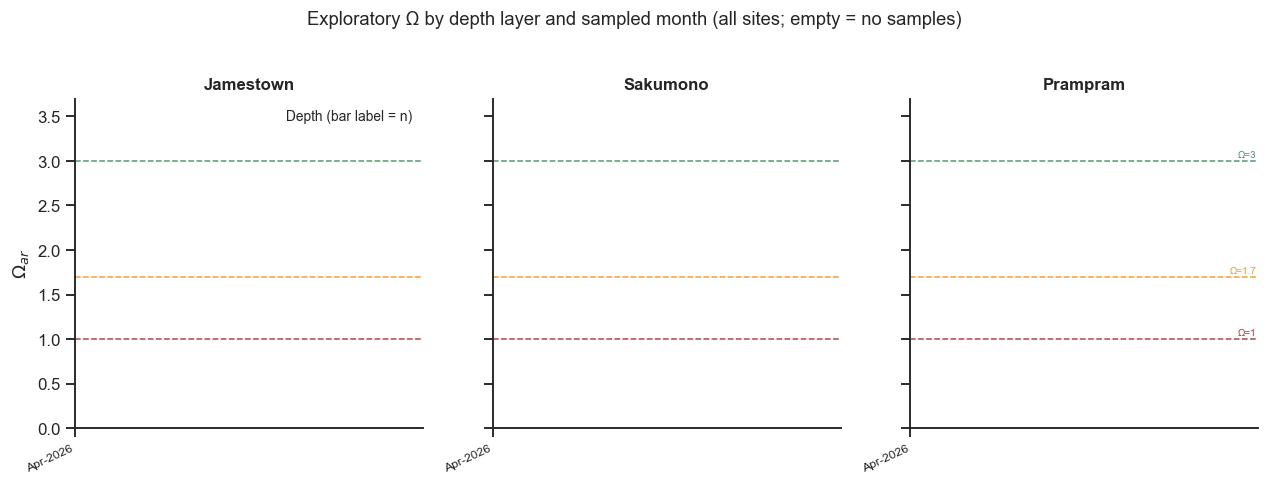


--- Depth×month sample counts (all sites) ---
  Jamestown:
    Empty DataFrame
    Columns: []
    Index: [Apr-2026]
  Sakumono:
    Empty DataFrame
    Columns: []
    Index: [Apr-2026]
  Prampram:
    Empty DataFrame
    Columns: []
    Index: [Apr-2026]


In [11]:
# Case-insensitive transect matcher: returns the west->east canonical names
# that are actually present in the data, matching regardless of case
# (pipeline data is lowercase, prelim sheet is capitalized).
def _match_transects(d, col, west_to_east):
    if "transect" not in col:
        return []
    present = {str(x).strip().lower() for x in d[col["transect"]].dropna().unique()}
    return [t for t in west_to_east if t.lower() in present]

# --- All-sites seasonal Omega + depth-by-season (report Figures 2 & 3) ---
# Honest exploratory versions: lines connect discrete survey points only (not
# continuous monitoring); n annotated on every point/bar; temperature overlaid
# only for sites with >=3 sampled months; empty depth-month cells shown as gaps.

# Year-aware month keys, e.g. "Apr-2025". Order is chronological across the dataset.
_MNAMES = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
def _ym_key(ts):
    ts = pd.to_datetime(ts, errors="coerce")
    if pd.isna(ts): return None
    return f"{_MNAMES[ts.month]}-{ts.year}"
SITE_PAL = {"Jamestown":"#D85A30","Sakumono":"#185FA5","Prampram":"#1D9E75","Ayitepa":"#9C27B0"}

def _with_mon(df, col):
    d = df.copy()
    if "date" in col:
        dts = pd.to_datetime(d[col["date"]], errors="coerce")
        d["_mon"] = dts.apply(_ym_key)
        d["_ord"] = dts.dt.year*100 + dts.dt.month
    return d

def _mon_order(d):
    """Chronological list of year-month labels present in the data."""
    pairs = d.dropna(subset=["_mon"]).drop_duplicates("_mon")[["_mon","_ord"]]
    return [m for m,_ in sorted(zip(pairs["_mon"], pairs["_ord"]), key=lambda t: t[1])]

def fig_seasonal_all_sites(df, col, surface_max=10.0, temp_min_months=3,
                           save_name="seasonal_all_sites"):
    if "transect" not in col or "date" not in col:
        print("need transect + date; skip"); return
    d = _with_mon(df, col)
    if "depth" in col:
        d = d[pd.to_numeric(d[col["depth"]], errors="coerce") < surface_max]
    MON_ORDER = _mon_order(d)
    order = _match_transects(d, col, WEST_TO_EAST)
    fig, ax1 = plt.subplots(figsize=(9.0, 5.1))
    for t in order:
        sub = d[d[col["transect"]] == t]
        g = sub.groupby("_mon")[col["omega_ar"]].agg(["mean","std","size"]).reindex(MON_ORDER)
        xs = [i for i in range(len(MON_ORDER)) if np.isfinite(g["mean"].iloc[i])]
        if not xs: continue
        ys = [g["mean"].iloc[i] for i in xs]; ns = [int(g["size"].iloc[i]) for i in xs]
        es = [g["std"].iloc[i] if np.isfinite(g["std"].iloc[i]) else 0 for i in xs]
        ax1.errorbar(xs, ys, yerr=es, fmt="o-", color=SITE_PAL.get(t,"0.3"), lw=2, ms=7,
                     capsize=3, elinewidth=1, label=f"{t}")
        for x,y,nn in zip(xs,ys,ns):
            ax1.annotate(f"n={nn}", (x,y), xytext=(0,7), textcoords="offset points",
                         ha="center", fontsize=7, color=SITE_PAL.get(t,"0.3"))
    # temperature only for sites with >= temp_min_months
    if "temp_insitu" in col:
        ax2 = ax1.twinx()
        drew = False
        for t in order:
            sub = d[d[col["transect"]] == t]
            g = sub.groupby("_mon")[col["temp_insitu"]].mean().reindex(MON_ORDER)
            if g.notna().sum() >= temp_min_months:
                xs = [i for i in range(len(MON_ORDER)) if np.isfinite(g.iloc[i])]
                ax2.plot(xs, [g.iloc[i] for i in xs], "x--", color=SITE_PAL.get(t,"0.5"),
                         lw=1, ms=7, alpha=0.5); drew = True
        ax2.set_ylabel(f"Surface T (°C) — dashed ×, sites with ≥{temp_min_months} months", fontsize=9)
        ax2.set_ylim(robust_limits(d[col["temp_insitu"]]) or (18,32))
    add_refs(ax1, "omega_ar", "y", label=True)
    # shade the lowest-observed-Omega month band (data-driven, not assumed August)
    monthly = d.groupby("_mon")[col["omega_ar"]].mean().reindex(MON_ORDER)
    if monthly.notna().any():
        lo_i = int(np.nanargmin(monthly.values))
        ax1.axvspan(lo_i-0.3, lo_i+0.3, color="#FAC775", alpha=0.25, zorder=0)
    ax1.set_xticks(range(len(MON_ORDER)))
    ax1.set_xticklabels(MON_ORDER, rotation=20, ha="right")
    ax1.set_ylabel(label_of("omega_ar"))
    _hi = (robust_limits(d[col["omega_ar"]]) or (2, 3.6))[1]
    ax1.set_ylim(0.9, max(3.65, _hi))   # floor includes the cited thresholds
    ax1.legend(loc="lower right", fontsize=9, ncol=2)
    ax1.set_title("Exploratory surface Ω by sampled month (all sites)", fontsize=12)
    fig.tight_layout(); _save(fig, save_name); plt.show()

def fig_depth_season_all_sites(df, col, save_name="depth_season_all_sites"):
    if "transect" not in col or "depth" not in col or "date" not in col:
        print("need transect + depth + date; skip"); return
    d = _with_mon(df, col)
    d["_layer"] = pd.cut(pd.to_numeric(d[col["depth"]], errors="coerce"),
                         [0,10,30,200], labels=["0-10m","10-30m","30m+"])
    MON_ORDER = _mon_order(d)
    layers = ["0-10m","10-30m","30m+"]; LCOL = {"0-10m":"#85B7EB","10-30m":"#378ADD","30m+":"#0C447C"}
    order = _match_transects(d, col, WEST_TO_EAST)
    if not order:
        print("no matching transects present; skip"); return
    fig, axes = plt.subplots(1, len(order), figsize=(3.9*len(order), 4.3), sharey=True, squeeze=False)
    for ai, t in enumerate(order):
        ax = axes[0][ai]; sub = d[d[col["transect"]] == t]
        piv = sub.pivot_table(index="_mon", columns="_layer", values=col["omega_ar"],
                              aggfunc="mean", observed=True).reindex(MON_ORDER)
        cnt = sub.pivot_table(index="_mon", columns="_layer", values=col["omega_ar"],
                              aggfunc="size", observed=True).reindex(MON_ORDER)
        x = np.arange(len(MON_ORDER)); w = 0.25
        for li, lay in enumerate(layers):
            if lay in piv.columns:
                vals = piv[lay].values
                sd = sub.pivot_table(index="_mon", columns="_layer", values=col["omega_ar"],
                                     aggfunc="std", observed=True).reindex(MON_ORDER)
                errs = sd[lay].values if lay in sd.columns else np.zeros_like(vals)
                errs = np.nan_to_num(errs)
                ax.bar(x+(li-1)*w, np.nan_to_num(vals), w, color=LCOL[lay],
                       yerr=errs, capsize=2, error_kw=dict(elinewidth=0.8, alpha=0.7),
                       label=lay if ai == 0 else None)
                for xi, v in enumerate(vals):
                    if np.isfinite(v):
                        nn = int(cnt[lay].iloc[xi]) if lay in cnt.columns and np.isfinite(cnt[lay].iloc[xi]) else 0
                        ax.annotate(f"{nn}", (x[xi]+(li-1)*w, v), xytext=(0,2),
                                    textcoords="offset points", ha="center", fontsize=6, color="0.3")
        add_refs(ax, "omega_ar", "y", label=(ai==len(order)-1))
        ax.set_xticks(x); ax.set_xticklabels(MON_ORDER, fontsize=8, rotation=25, ha="right")
        ax.set_title(t, fontsize=11); ax.set_ylim(0, 3.7)
        if ai == 0: ax.set_ylabel(label_of("omega_ar"))
        try: sns.despine(ax=ax)
        except Exception: pass
    axes[0][0].legend(title="Depth (bar label = n)", fontsize=8, title_fontsize=9, loc="upper right")
    fig.suptitle("Exploratory Ω by depth layer and sampled month (all sites; empty = no samples)",
                 fontsize=12, y=1.02)
    fig.tight_layout(); _save(fig, save_name); plt.show()
    # count summary so sparse cells are explicit
    print("\n--- Depth×month sample counts (all sites) ---")
    for t in order:
        sub = d[d[col["transect"]] == t]
        cnt = sub.pivot_table(index="_mon", columns="_layer", values=col["omega_ar"],
                              aggfunc="size", observed=True).reindex(MON_ORDER).fillna(0).astype(int)
        print(f"  {t}:"); print("   ", cnt.to_string().replace("\n","\n    "))

fig_seasonal_all_sites(df, col)
fig_depth_season_all_sites(df, col)


## 9. PhD cruise (April 2026): vertical structure & temperature model

Reads `analysis_ready.csv`, averages replicates (the TA replicate scatter is random, not bias, so averaging is the right estimate), and produces the two PhD figures: the **vertical profile** (Ω/pH/pCO₂ vs depth) and the **Ω-temperature regression** that is the premise for predicting carbonate structure from CTD profiles. R²≈0.5 from one cruise — a starting relationship, not a finished model.

Loaded PhD cruise: 28 samples after replicate averaging
saved oa_figures\phd_vertical_profile.png


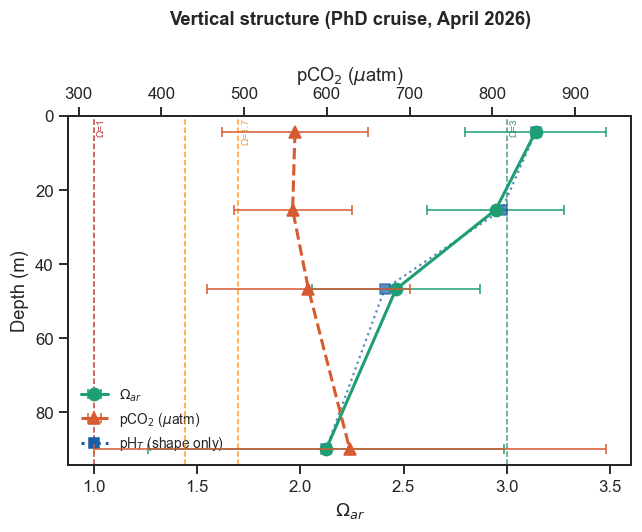

saved oa_figures\phd_omega_temp_model.png


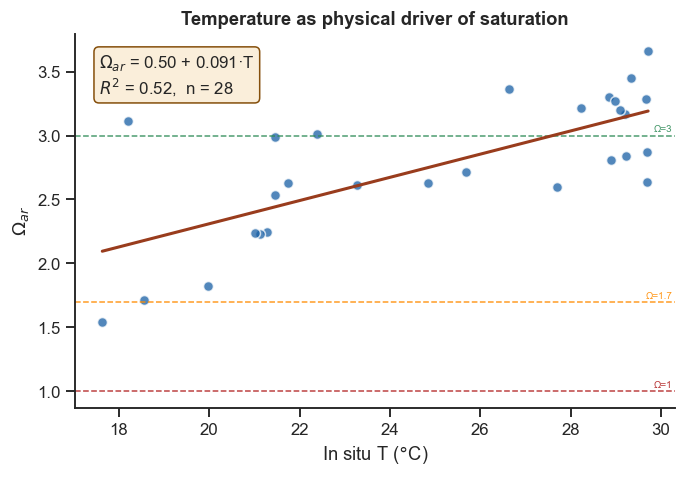


--- PhD model: data summary ---
  - Omega_ar = 0.50 + 0.091*T;  R2 = 0.52 (n=28)
  - Single-cruise relationship: half the saturation variance tracks temperature (water mass).
  - Robustness: re-run on PASS-only rows to confirm the slope holds before trusting it.


In [12]:
# --- PhD cruise (April 2026) vertical structure + temperature->Omega model ---
# Point INPUT_PHD at analysis_ready.csv. Reuses the resolver and refs; collapses
# replicates by sample tag (mean) since the replicate TA scatter is random, not bias.

INPUT_PHD = Path(r"C:\Users\OA_2023-03\Projects\oa_pipeline\outputs\oa_stage4_outputs\data\analysis_ready.csv")   # EDIT if needed

def load_phd(path):
    d = pd.read_csv(path)
    c = resolve(d)
    # collapse (R) replicate suffixes -> mean per base sample
    if "sample_tag" in d.columns:
        d["_base"] = d["sample_tag"].astype(str).str.replace(r"\(R\)", "", regex=True)
        numc = [c[k] for k in ["ph","omega_ar","pco2","ta","dic","temp_insitu","sal","depth","lat","lon"] if k in c]
        keepc = [c[k] for k in ["transect","station","cruise"] if k in c]
        for col_ in numc: d[col_] = pd.to_numeric(d[col_], errors="coerce")
        agg = {x:"mean" for x in numc}; agg.update({x:"first" for x in keepc})
        d = d.groupby("_base", as_index=False).agg(agg)
    else:
        for k in ["ph","omega_ar","pco2","ta","temp_insitu","sal","depth"]:
            if k in c: d[c[k]] = pd.to_numeric(d[c[k]], errors="coerce")
    return d, c

def fig_phd_vertical(d, c, save_name="phd_vertical_profile"):
    """Layer-mean vertical profile of Omega_ar, pH, pCO2 (depth increases downward)."""
    if "depth" not in c: print("no depth; skip"); return
    d = d.copy()
    d["_layer"] = pd.cut(pd.to_numeric(d[c["depth"]], errors="coerce"),
                         [0,15,35,70,120], labels=["<15","15-35","35-70","70+"])
    agg = {"depth": (c["depth"],"mean")}
    for v in ["omega_ar","ph","pco2"]:
        if v in c:
            agg[v] = (c[v],"mean"); agg[v+"_sd"] = (c[v],"std")
    lp = d.groupby("_layer", observed=True).agg(**agg)
    lsd = d.groupby("_layer", observed=True).agg(
        **{v:(c[v],"std") for v in ["omega_ar","pco2"] if v in c})
    fig, ax1 = plt.subplots(figsize=(6,5))
    if "omega_ar" in c:
        l1=ax1.errorbar(lp["omega_ar"], lp["depth"], xerr=lsd["omega_ar"].fillna(0),
                        fmt="o-", color="#1D9E75", lw=2, ms=8, capsize=3, elinewidth=1,
                        label=label_of("omega_ar"))
        ax1.set_xlabel(label_of("omega_ar")); add_refs(ax1, "omega_ar", axis="x", label=True)
    ax1.set_ylabel(label_of("depth")); ax1.invert_yaxis()
    if "pco2" in c:
        ax2 = ax1.twiny()
        l2=ax2.errorbar(lp["pco2"], lp["depth"], xerr=lp.get("pco2_sd"), fmt="^--", color="#D85A30", lw=2, ms=8, capsize=3, elinewidth=1, label=label_of("pco2"))
        ax2.set_xlabel(label_of("pco2")); add_refs(ax2, "pco2", axis="x")
    handles, labels = [], []
    if "omega_ar" in c: handles.append(l1); labels.append(label_of("omega_ar"))
    if "pco2" in c: handles.append(l2); labels.append(label_of("pco2"))
    if "ph" in c:
        l3 = ax1.plot([], [], "s:", color="#185FA5", lw=2, ms=7, label=label_of("ph"))[0]
        # pH on its own scaled overlay (normalised to omega axis range for shape only)
        ph = lp["ph"]; om = lp["omega_ar"] if "omega_ar" in c else ph
        if ph.notna().any() and om.notna().any():
            ph_s = (ph - ph.min())/(ph.max()-ph.min()+1e-9)*(om.max()-om.min())+om.min()
            ax1.plot(ph_s, lp["depth"], "s:", color="#185FA5", lw=1.5, ms=6, alpha=0.7)
        handles.append(l3); labels.append(label_of("ph")+" (shape only)")
    ax1.legend(handles, labels, loc="lower left", fontsize=9, framealpha=0.9)
    ax1.set_title("Vertical structure (PhD cruise, April 2026)", pad=26)
    fig.tight_layout(); _save(fig, save_name); plt.show()

def fig_phd_model(d, c, save_name="phd_omega_temp_model"):
    """Omega_ar vs in-situ temperature with OLS fit + R^2 (the modelling premise)."""
    if "temp_insitu" not in c or "omega_ar" not in c: print("need T + Omega; skip"); return
    x = pd.to_numeric(d[c["temp_insitu"]], errors="coerce").to_numpy()
    y = pd.to_numeric(d[c["omega_ar"]], errors="coerce").to_numpy()
    m = np.isfinite(x) & np.isfinite(y); x, y = x[m], y[m]
    b1, b0 = np.polyfit(x, y, 1); r2 = np.corrcoef(x, y)[0,1]**2
    fig, ax = plt.subplots(figsize=(6.4,4.5))
    ax.scatter(x, y, s=42, alpha=0.75, color="#185FA5", edgecolor="white")
    xx = np.linspace(x.min(), x.max(), 50); ax.plot(xx, b0+b1*xx, color="#993C1D", lw=2)
    add_refs(ax, "omega_ar", axis="y", label=True)
    ax.text(0.04, 0.95, f"$\\Omega_{{ar}}$ = {b0:.2f} + {b1:.3f}\u00b7T\n$R^2$ = {r2:.2f},  n = {m.sum()}",
            transform=ax.transAxes, va="top", fontsize=11,
            bbox=dict(boxstyle="round", fc="#FAEEDA", ec="#854F0B"))
    ax.set_xlabel(label_of("temp_insitu")); ax.set_ylabel(label_of("omega_ar"))
    ax.set_title("Temperature as physical driver of saturation")
    try: sns.despine(ax=ax)
    except Exception: pass
    fig.tight_layout(); _save(fig, save_name); plt.show()
    print(f"\n--- PhD model: data summary ---\n  - Omega_ar = {b0:.2f} + {b1:.3f}*T;  R2 = {r2:.2f} (n={m.sum()})")
    print("  - Single-cruise relationship: half the saturation variance tracks temperature (water mass).")
    print("  - Robustness: re-run on PASS-only rows to confirm the slope holds before trusting it.")

try:
    dphd, cphd = load_phd(INPUT_PHD)
    print(f"Loaded PhD cruise: {len(dphd)} samples after replicate averaging")
    fig_phd_vertical(dphd, cphd)
    fig_phd_model(dphd, cphd)
except FileNotFoundError:
    print(f"PhD file {INPUT_PHD} not found - set INPUT_PHD to your analysis_ready.csv path")


## 10. Figures for Prof Amala — report & slides

In [13]:
# --- Which figures go to Prof Amala (report + slides) ---
# Running the cells above writes PNGs into OUTDIR. The set used in the
# milestone report and deck:
#
#   Section 1 (preliminary):
#     eastwest_omega_slide.png   - clean Omega box plot (SLIDE)
#     eastwest_multipanel.png    - all 6 vars by transect (REPORT appendix)
#     timeseries_by_cruise.png   - seasonal signal incl. August upwelling
#     by_transect_boxplots.png   - original distributions (optional)
#
#   Section 2 (PhD cruise):
#     phd_vertical_profile.png   - Omega/pH/pCO2 vs depth (REPORT + SLIDE)
#     phd_omega_temp_model.png   - Omega-T regression, R^2 (REPORT + SLIDE)
#
# Note: the seasonal *line* figure (August minimum) is intentionally NOT a box
# plot - a box plot would hide the through-year trajectory that is the headline.
# Keep it as the cruise/time-series figure.
print("Figures written to:", OUTDIR.resolve())
import os
if OUTDIR.exists():
    for f in sorted(os.listdir(OUTDIR)):
        if f.endswith(".png"): print("  ", f)


Figures written to: C:\Users\OA_2023-03\Projects\oa_pipeline\notebooks\oa_figures
   by_transect_boxplots.png
   crossplots.png
   depth_season_all_sites.png
   eastwest_multipanel.png
   eastwest_omega_slide.png
   phd_omega_temp_model.png
   phd_vertical_profile.png
   season_depth_profiles.png
   seasonal_all_sites.png
   station_map.png
   timeseries_by_cruise.png


## Duplicate-based precision (GOA-ON Cookbook)

Precision from duplicate pairs using **precision = 2.2 x (SD / sqrt(n))** (SOP 22/23; Dickson et al. 2007), reported against the operative quality tier. Field duplicates capture total uncertainty (sampling + handling + analysis); analytical duplicates capture analytical error only. Switch type/tier in the config cell (`DUPLICATE_TYPE`, `QUALITY_TIER`). Needs `replicate_id` + `sample_id` to pair duplicates, so this is most useful when `INPUT` points at the pipeline's `analysis_ready.csv`; on data without identifiable pairs it skips cleanly.

• Duplicate type: FIELD (total uncertainty: sampling + analytical). Quality tier: WEATHER.
• Reported precision is compared against the WEATHER-quality tolerance (operative tier for mapping current state). The CLIMATE-quality tolerance is shown for reference only and is not enforced.



,variable,n_pairs,SD_pooled,precision_2.2_SD_over_sqrtN,weather_tolerance,weather_verdict,climate_tolerance_ref,mean_signal
0,ta,10,49.4760,34.4205,10.00,EXCEEDS,1.000,2301.89
1,ph,10,0.0491,0.0342,0.02,EXCEEDS,0.005,7.98
2,dic,10,57.4285,39.9531,10.00,EXCEEDS,2.000,2044.33



NOTE: ta, ph, dic exceed the weather tolerance. For FIELD duplicates this reflects total uncertainty (site heterogeneity + handling + analysis), not analytical error alone.


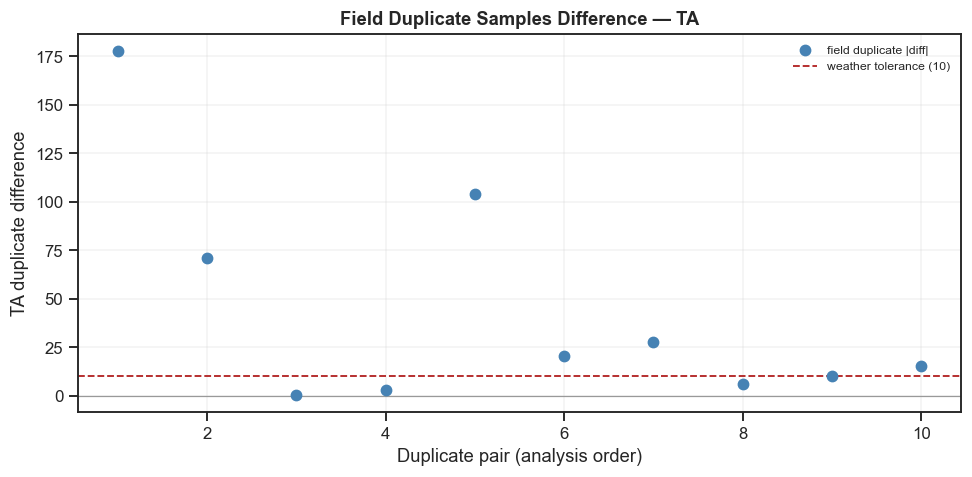

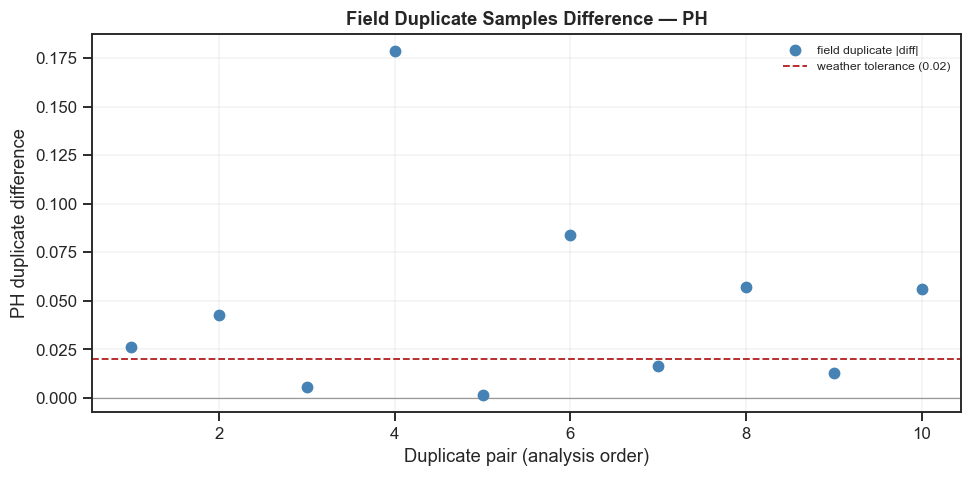

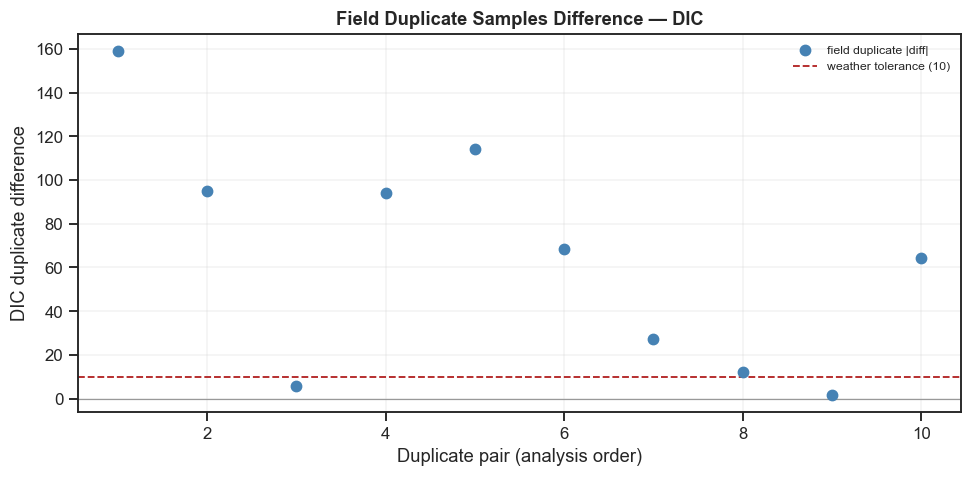

In [14]:
# --- Duplicate-based precision + control charts ---
def run_precision_section(df, col):
    try:
        sys.path.insert(0, str(Path.cwd() / "src"))
        from oa_pipeline import duplicate_precision as _dp
    except Exception as e:
        print(f"duplicate_precision unavailable ({e}); skipping precision section.")
        return

    cfg = {
        "duplicate_type": globals().get("DUPLICATE_TYPE", "field"),
        "quality_tier":   globals().get("QUALITY_TIER", "weather"),
    }
    res = _dp.compute_precision(df, cfg)
    for n in res.notes:
        print("\u2022", n)
    print()

    if res.summary.empty:
        print("No duplicate pairs found - precision not computed. "
              "(Point INPUT at analysis_ready.csv, which carries replicate_id/sample_id.)")
        return

    try:
        from IPython.display import display
        display(res.summary)
    except Exception:
        print(res.summary.to_string(index=False))

    n_pairs = int(res.summary["n_pairs"].max())
    verdict_col = res.summary.filter(like="verdict").iloc[:, 0]
    exceeded = res.summary[verdict_col == "EXCEEDS"]
    print()
    if not exceeded.empty:
        vars_ex = ", ".join(exceeded["variable"].tolist())
        print(f"NOTE: {vars_ex} exceed the {cfg['quality_tier']} tolerance. For FIELD "
              f"duplicates this reflects total uncertainty (site heterogeneity + "
              f"handling + analysis), not analytical error alone.")
    if n_pairs < 10:
        print(f"NOTE: only {n_pairs} duplicate pairs (cookbook recommends >=10); "
              f"treat precision as indicative and outlier-sensitive - inspect the "
              f"control chart and check field/bench records for high-spread pairs.")

    tier = cfg["quality_tier"]
    for var in ("ta", "ph", "dic"):
        tol = _dp.DUPLICATE_PRECISION_DEFAULTS["tolerances"].get(var, {}).get(tier)
        fig = _dp.make_control_chart(res.per_pair, var, tolerance=tol,
                                     duplicate_type=cfg["duplicate_type"])
        if fig is not None:
            try:
                from IPython.display import display
                display(fig)
            except Exception:
                pass
            if globals().get("SAVE", False):
                fig.savefig(OUTDIR / f"duplicate_precision_{var}.png",
                            dpi=150, bbox_inches="tight")

run_precision_section(df, col)


---
### Notes & next steps

- To run on the pipeline output instead, set `INPUT` to your `analysis_ready.csv` —
  the column resolver handles the different names automatically.
- Turn reference guides off with `REFS = False` in the config cell.
- Styling: if `src/viz/style.py` is importable, the notebook uses your
  `set_pub_defaults()` and `chem()`; otherwise it falls back to seaborn defaults.
- The station map uses cartopy coastlines when available and falls back to a plain
  geographic scatter otherwise — no ETOPO file required. For a bathymetric backdrop,
  extend the map cell with an ETOPO subset later.
- Recycled from the old scripts: seasonal-profile grid and transect boxplots
  (`make_figures.py`), the cartopy map approach (`make_profiles.py`), and the
  `chem()` label helper / `set_pub_defaults()` (`src/viz/style.py`). The flux
  ribbon and heatbox sections were left out (need flux/CTD data not in the prelim set).